# Integrating Pandas with Matplotlib

---

### Table of Contents
1. The Standard Data Science Workflow
2. Example 1: Bar Chart of Aggregated Data
3. Example 2: Scatter Plot of Relationships
4. Example 3: Time Series Plot

---

## 1. The Standard Data Science Workflow
- In practice, data rarely starts in a format that's ready for plotting.
- The standard workflow is a powerful combination:
  1. Load and Prepare Data: Use Pandas to load, clean, and filter data.
  2. Aggregate Data: Use Pandas' `.groupby()` or other methods to summarize the
     data into a plottable form.
  3. Visualize Data: Use Matplotlib's Object-Oriented interface to create a
     customized, publication-quality plot from the aggregated data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Setup: Load our sample sales data ---
DATA_FOLDER = "pandas_data"
file_path = os.path.join(DATA_FOLDER, "sample_sales_data.csv")

try:
    df = pd.read_csv(file_path, parse_dates=["OrderDate"])
    df["TotalPrice"] = df["Price"] * df["Quantity"]
    print("--- Loaded and Prepared Sample DataFrame ---")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The data file was not found at '{file_path}'")
    print("Please run '04_reading_and_writing_data.py' first to create it.")
    df = pd.DataFrame()

--- Loaded and Prepared Sample DataFrame ---
   OrderID   Product     Category   Price  Quantity  OrderDate  TotalPrice
0      101    Laptop  Electronics  1200.0         1 2025-01-15      1200.0
1      102     Mouse  Electronics    25.5         2 2025-01-15        51.0
2      103  Keyboard  Electronics    75.0         1 2025-01-16        75.0
3      104   Monitor  Electronics   300.0         2 2025-01-17       600.0
4      105     Mouse  Accessories    27.0         3 2025-01-18        81.0



---

## 2. Example 1: Bar Chart of Aggregated Data
- Goal: Create a bar chart showing total revenue per product category.

--- Plot 1: Bar Chart from GroupBy ---


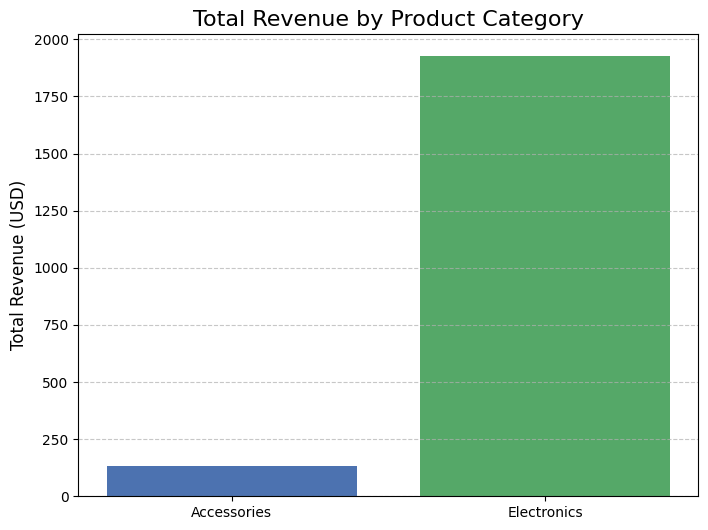

Generated Bar Chart.


In [6]:
if not df.empty:
    print("--- Plot 1: Bar Chart from GroupBy ---")

    # Aggregate data with Pandas
    category_revenue = df.groupby("Category")["TotalPrice"].sum()

    # Visualize with Mathplotlib
    fig1, ax1 = plt.subplots(figsize=(8, 6))

    ax1.bar(
        category_revenue.index,  # x-values are the categories (the Series index)
        category_revenue.to_numpy(),  # y-values are the aggregated revenues (converted to NumPy array)
        color=["#4c72b0", "#55a868"],  # A custom color scheme
    )
    ax1.set_title("Total Revenue by Product Category", fontsize=16)
    ax1.set_ylabel("Total Revenue (USD)", fontsize=12)
    ax1.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
    print("Generated Bar Chart.")


---

## 3. Example 2: Scatter Plot of Relationships
- Goal: Investigate the relationship between the price of an item and its quantity sold.

--- Plot 2: Scatter Plot ---


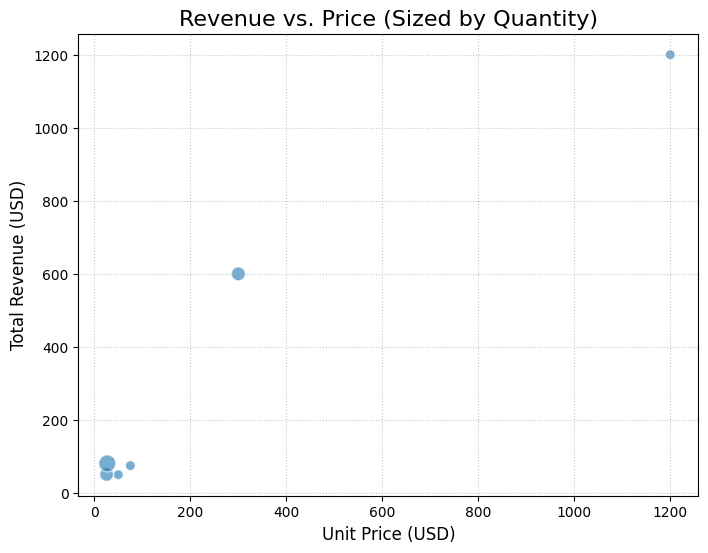

Generated Scatter Plot.


In [ ]:
if not df.empty:
    print("--- Plot 2: Scatter Plot ---")

    # Data is already prepared in columns, no aggregation needed. Let's visualize:
    fig2, ax2 = plt.subplots(figsize=(8, 6))

    # We can even use a third variable to control the size of the points
    point_sizes = df["Quantity"] * 50

    ax2.scatter(
        df["Price"],
        df["TotalPrice"],
        s=point_sizes,  # s = size
        alpha=0.6,
        edgecolors="w",  # Add a white edge to markers
    )
    ax2.set_title("Revenue vs. Price (Sized by Quantity)", fontsize=16)
    ax2.set_xlabel("Unit Price (USD)", fontsize=12)
    ax2.set_ylabel("Total Revenue (USD)", fontsize=12)
    ax2.grid(True, linestyle=":", alpha=0.7)
    plt.show()
    print("Generated Scatter Plot.")



---

## 4. Example 3: Time Series Plot
- Goal: Plot the total sales revenue over time

--- Plot 3: Time Series Plot
Data to plot:
 OrderDate
2025-01-15    1251.0
2025-01-16      75.0
2025-01-17     600.0
2025-01-18     131.0
Name: TotalPrice, dtype: float64
Generated Time Series Plot.


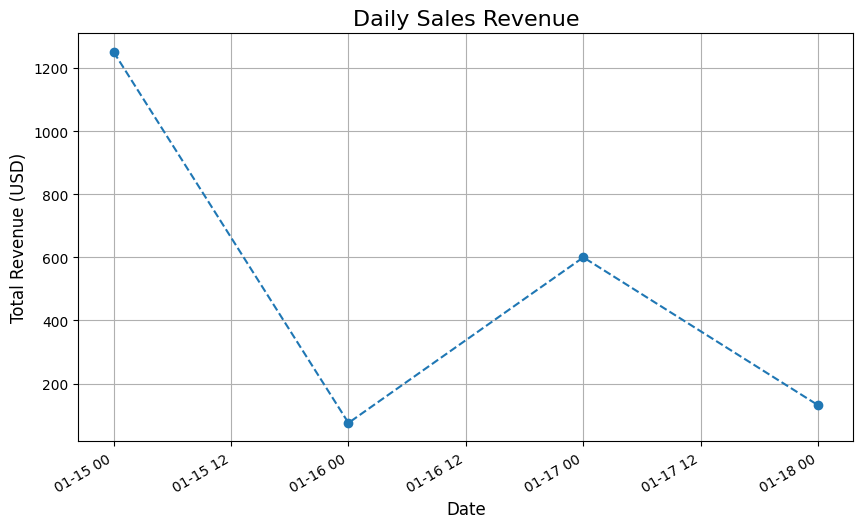

In [4]:
if not df.empty:
    print("--- Plot 3: Time Series Plot")

    # Aggregate data by date
    daily_revenue = df.groupby("OrderDate")["TotalPrice"].sum()
    print("Data to plot:\n", daily_revenue)

    # Visualize with Matplotlib
    fig3, ax3 = plt.subplots(figsize=(10, 6))

    ax3.plot(daily_revenue.index, daily_revenue.to_numpy(), marker="o", linestyle="--")
    ax3.set_title("Daily Sales Revenue", fontsize=16)
    ax3.set_xlabel("Date", fontsize=12)
    ax3.set_ylabel("Total Revenue (USD)", fontsize=12)
    ax3.grid(True)

    # Improve date formatting on the x-axis
    fig3.autofmt_xdate()
    print("Generated Time Series Plot.")
    
    plt.show()